In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
import re

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.model_selection import train_test_split

from sklearn.naive_bayes import MultinomialNB

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

## Import Libraries

In [44]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## Download NLTK Resources

In [45]:
df = pd.read_csv("3) Sentiment dataset.csv")

df.head()

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


In [46]:
df["Sentiment"] = df["Sentiment"].str.strip()

df = df[df["Sentiment"].isin(["Positive", "Negative", "Neutral"])]

df.reset_index(drop=True, inplace=True)

df["Sentiment"].value_counts()

,count
Sentiment,
Positive,45
Neutral,18
Negative,4


# Remove extra spaces from sentiment labels
#Keep only the three main sentiment classes
# Check the remaining classes

## Load the Dataset

In [47]:
df.shape

(67, 15)

## Explore the Dataset

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67 entries, 0 to 66
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0.1  67 non-null     int64  
 1   Unnamed: 0    67 non-null     int64  
 2   Text          67 non-null     object 
 3   Sentiment     67 non-null     object 
 4   Timestamp     67 non-null     object 
 5   User          67 non-null     object 
 6   Platform      67 non-null     object 
 7   Hashtags      67 non-null     object 
 8   Retweets      67 non-null     float64
 9   Likes         67 non-null     float64
 10  Country       67 non-null     object 
 11  Year          67 non-null     int64  
 12  Month         67 non-null     int64  
 13  Day           67 non-null     int64  
 14  Hour          67 non-null     int64  
dtypes: float64(2), int64(6), object(7)
memory usage: 8.0+ KB


In [49]:
df.describe(include="all")

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
count,67.000000,67.00000,67,67,67,67,67,67,67.000000,67.000000,67,67.0,67.000000,67.000000,67.000000
unique,NaN,NaN,67,3,67,67,4,67,NaN,NaN,23,NaN,NaN,NaN,NaN
top,NaN,NaN,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Instagram,#Nature #Park,NaN,NaN,USA,NaN,NaN,NaN,NaN
freq,NaN,NaN,1,45,1,1,23,1,NaN,NaN,6,NaN,NaN,NaN,NaN
mean,178.522388,179.80597,NaN,NaN,NaN,NaN,NaN,NaN,18.940299,37.746269,NaN,2023.0,3.014925,18.701493,14.313433
std,286.558226,288.04478,NaN,NaN,NaN,NaN,NaN,NaN,5.928566,11.692193,NaN,0.0,3.719289,8.259090,4.004577
min,0.000000,0.00000,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,10.000000,NaN,2023.0,1.000000,1.000000,0.000000
25%,16.500000,16.50000,NaN,NaN,NaN,NaN,NaN,NaN,15.000000,30.000000,NaN,2023.0,1.000000,15.000000,12.000000
50%,34.000000,35.00000,NaN,NaN,NaN,NaN,NaN,NaN,19.000000,37.000000,NaN,2023.0,1.000000,19.000000,15.000000
75%,50.500000,51.50000,NaN,NaN,NaN,NaN,NaN,NaN,22.500000,45.000000,NaN,2023.0,1.500000,25.500000,17.000000


In [50]:
df.isnull().sum()

,0
Unnamed: 0.1,0
Unnamed: 0,0
Text,0
Sentiment,0
Timestamp,0
User,0
Platform,0
Hashtags,0
Retweets,0
Likes,0


In [51]:
df.duplicated().sum()

np.int64(0)

In [52]:
df = df[["Text", "Sentiment"]]

df.head()

,Text,Sentiment
0,Enjoying a beautiful day at the park! ...,Positive
1,Traffic was terrible this morning. ...,Negative
2,Just finished an amazing workout! 💪 ...,Positive
3,Excited about the upcoming weekend getaway! ...,Positive
4,Trying out a new recipe for dinner tonight. ...,Neutral


## Keep Required Columns

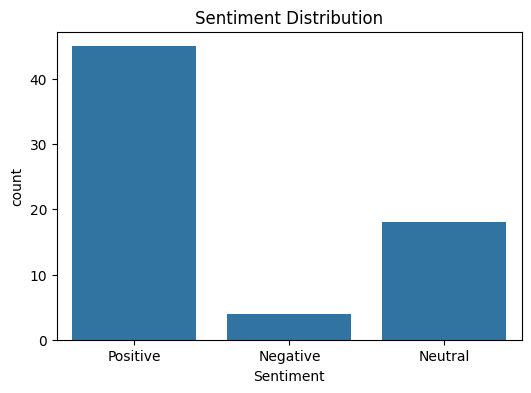

In [53]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Sentiment"
)

plt.title("Sentiment Distribution")

plt.show()

## Visualize the Sentiment Distribution

In [54]:
stemmer = PorterStemmer()

stop_words = set(stopwords.words("english"))

## Text Preprocessing

In [55]:
def preprocess_text(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    words = text.split()

    words = [
        stemmer.stem(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

In [56]:
df["Clean_Text"] = df["Text"].apply(preprocess_text)

df.head()

,Text,Sentiment,Clean_Text
0,Enjoying a beautiful day at the park! ...,Positive,enjoy beauti day park
1,Traffic was terrible this morning. ...,Negative,traffic terribl morn
2,Just finished an amazing workout! 💪 ...,Positive,finish amaz workout
3,Excited about the upcoming weekend getaway! ...,Positive,excit upcom weekend getaway
4,Trying out a new recipe for dinner tonight. ...,Neutral,tri new recip dinner tonight


In [57]:
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(df["Clean_Text"])

In [58]:
X.shape

(67, 243)

In [59]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y = encoder.fit_transform(df["Sentiment"])

In [60]:
print(encoder.classes_)

['Negative' 'Neutral' 'Positive']


In [61]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [62]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [63]:
y_pred = log_model.predict(X_test)

In [72]:
precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

In [65]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.00      0.00      0.00         4
           2       0.64      1.00      0.78         9

    accuracy                           0.64        14
   macro avg       0.21      0.33      0.26        14
weighted avg       0.41      0.64      0.50        14



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


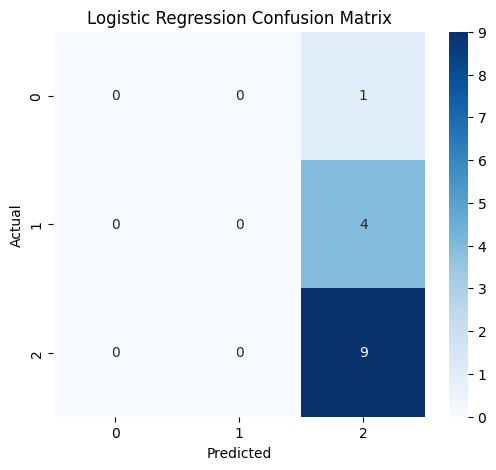

In [66]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.show()

In [67]:
print(df["Sentiment"].unique())

['Positive' 'Negative' 'Neutral']


In [68]:
df["Sentiment"].value_counts()

,count
Sentiment,
Positive,45
Neutral,18
Negative,4


In [69]:
nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)

In [70]:
nb_accuracy = accuracy_score(y_test, nb_pred)
nb_precision = precision_score(y_test, nb_pred, average="weighted", zero_division=0)
nb_recall = recall_score(y_test, nb_pred, average="weighted", zero_division=0)
nb_f1 = f1_score(y_test, nb_pred, average="weighted", zero_division=0)

print("Accuracy:", nb_accuracy)
print("Precision:", nb_precision)
print("Recall:", nb_recall)
print("F1 Score:", nb_f1)

Accuracy: 0.6428571428571429
Precision: 0.41326530612244905
Recall: 0.6428571428571429
F1 Score: 0.5031055900621119


In [71]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Naive Bayes"],
    "Accuracy": [accuracy, nb_accuracy],
    "Precision": [precision, nb_precision],
    "Recall": [recall, nb_recall],
    "F1 Score": [f1, nb_f1]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.642857,0.413265,0.642857,0.503106
1,Naive Bayes,0.642857,0.413265,0.642857,0.503106


## Conclusion

This project implemented an NLP pipeline for sentiment analysis. Text preprocessing included lowercase conversion, punctuation removal, stopword removal, and stemming. TF-IDF was used to convert text into numerical features.

Logistic Regression and Naive Bayes were trained and evaluated using Accuracy, Precision, Recall, and F1 Score. The models were compared to identify the better classifier for the filtered sentiment dataset


The dataset was highly imbalanced after filtering, with many more Positive samples than Negative samples, which limited the model's ability to predict minority classes.